Import Libraries

In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

2. Set Random Seeds and Device

In [51]:
torch.manual_seed(42)
np.random.seed(42)

Upload Dataset and Description of it

In [52]:
data = pd.read_csv('/content/datset_used.csv')
print("\nFirst 5 rows of the dataset:")
print(data.head())
print("\nDataset Description:")
print(data.describe())


First 5 rows of the dataset:
  Type_of_aggregates  Curing_age_(days)  Cs_(Mpa)  Er_(ohm-cm)  UPV_(m/s)
0            Rounded                  3    5.2154       5.8654  2440.2989
1            Rounded                  3    5.1528       5.9471  2417.9562
2            Rounded                  3    5.6877       5.9965  2429.9277
3            Rounded                  3    5.1476       5.8751  2435.0202
4            Rounded                  3    5.3406       5.8654  2408.7969

Dataset Description:
       Curing_age_(days)     Cs_(Mpa)  Er_(ohm-cm)    UPV_(m/s)
count        4420.000000  4420.000000  4420.000000  4420.000000
mean           40.443439    31.193113     6.760444  3808.959267
std            33.308785     9.588822     2.970590   561.041125
min             3.000000     5.082300     1.831200  2345.981200
25%            14.000000    24.962400     4.639225  3364.670525
50%            28.000000    31.853700     6.070350  3722.880700
75%            60.000000    36.075400     7.461300  4357

Changing Type Aggregate to number(Reason neural network not take string as input)

In [53]:
data['Type_of_aggregates'] = data['Type_of_aggregates'].astype('category')
print(dict(enumerate(data['Type_of_aggregates'].cat.categories)))
data['Type_of_aggregates'] = data['Type_of_aggregates'].cat.codes

{0: 'Crushed', 1: 'Recycled', 2: 'Rounded', 3: 'Volcanic'}


Check if their is any missing value in dataset

In [54]:
print("\nMissing values in each column:")
print(data.isnull().sum())


Missing values in each column:
Type_of_aggregates    0
Curing_age_(days)     0
Cs_(Mpa)              0
Er_(ohm-cm)           0
UPV_(m/s)             0
dtype: int64


Numerical features in Dataset

In [55]:
numerical_features = ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']

# Check if all numerical features exist
for feature in numerical_features:
    if feature not in data.columns:
        raise ValueError(f"Numerical feature '{feature}' not found in the dataset.")

Normalisation of input(numericals features)

In [56]:
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

X = data.drop('Cs_(Mpa)', axis=1)
y = data['Cs_(Mpa)']

target_scaler = StandardScaler()
y = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

In [57]:
# Convert All Features to Numeric Format and Handle Missing Values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = np.nan_to_num(y, nan=0.0)

Data Splitting For Training and Testing -Split Dataset into Training (70%), Validation (15%), and Test (15%) Sets

In [58]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)  # 0.1765 * 0.85 ≈ 0.15

In [59]:
# Check for GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


Changing Array to Tensor

In [60]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

Define the Neural Network Model

In [61]:
class ConcreteStrengthANN(nn.Module):
    def __init__(self, input_size, hidden_layer_size=256):
        super(ConcreteStrengthANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_layer_size)
        self.bn1 = nn.BatchNorm1d(hidden_layer_size)
        self.fc2 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.bn2 = nn.BatchNorm1d(hidden_layer_size)
        self.fc3 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.bn3 = nn.BatchNorm1d(hidden_layer_size)
        self.fc4 = nn.Linear(hidden_layer_size, hidden_layer_size // 2)
        self.bn4 = nn.BatchNorm1d(hidden_layer_size // 2)
        self.fc5 = nn.Linear(hidden_layer_size // 2, 1)
        self.dropout = nn.Dropout(0.2)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.activation(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.activation(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.activation(self.bn4(self.fc4(x)))
        x = self.dropout(x)
        x = self.fc5(x)  # No activation on output layer
        return x

Instantiate the Model and Move to Device

In [62]:
input_size = X_train.shape[1]
model = ConcreteStrengthANN(input_size).to(device)
print("\nNeural Network Architecture:")
print(model)


Neural Network Architecture:
ConcreteStrengthANN(
  (fc1): Linear(in_features=4, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (activation): Tanh()
)


GIVING WEIGHTAGE TO LOSS FUNCTION

In [63]:
criterion_data = nn.L1Loss()

A = 7.2086
B = 1
C = 0.4238
D = 0.7560
F = -0.4272

Physics-Informed Loss Function Based on the Empirical Equation

In [64]:
def physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, predicted_Cs, scaler, target_scaler):
    """
    Computes the physics-informed loss based on the empirical equation:
    Cs = A * log(age + 1) + C * exp(D * (UPV / 1000)) + F * log(ER)

    Parameters:
    - age_scaled: Scaled age tensor
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - predicted_Cs: Predicted Cs tensor (scaled)
    - scaler: Fitted StandardScaler object for inputs
    - target_scaler: Fitted StandardScaler object for target
    """
    epsilon = 1e-6


    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]


    empirical_Cs = (
        A * torch.log(age_unscaled + B + epsilon) +
        C * torch.exp(D * (UPV_unscaled / 1000)) +
        F * torch.log(ER_unscaled + epsilon)
    )


    empirical_Cs_scaled = (empirical_Cs - target_scaler.mean_[0]) / target_scaler.scale_[0]
    empirical_Cs_scaled = empirical_Cs_scaled.to(device)


    loss_phy = torch.mean(torch.abs(predicted_Cs - empirical_Cs_scaled))

    return loss_phy

Boundary Loss Function to Enforce Constraints

In [65]:
def boundary_loss(predicted_Cs, UPV_scaled, ER_scaled, age_scaled, scaler, target_scaler):
    """
    Penalizes predictions that fall outside the specified ranges:
    Cs: 0 ≤ Cs ≤ 150
    UPV: 1000 ≤ UPV ≤ 6000
    ER: 10 ≤ ER ≤ 100
    Age: 0 ≤ Age ≤ 1000

    Parameters:
    - predicted_Cs: Predicted Cs tensor (scaled)
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - age_scaled: Scaled age tensor
    - scaler: Fitted StandardScaler object for inputs
    - target_scaler: Fitted StandardScaler object for target
    """

    Cs_lower = 0.0
    Cs_upper = 150.0
    UPV_lower = 1000.0
    UPV_upper = 6000.0
    ER_lower = 10.0
    ER_upper = 100.0
    Age_lower = 0.0
    Age_upper = 1000.0


    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]


    predicted_Cs_unscaled = predicted_Cs * target_scaler.scale_[0] + target_scaler.mean_[0]


    loss_lower_Cs = torch.mean(torch.relu(Cs_lower - predicted_Cs_unscaled))
    loss_upper_Cs = torch.mean(torch.relu(predicted_Cs_unscaled - Cs_upper))


    loss_lower_UPV = torch.mean(torch.relu(UPV_lower - UPV_unscaled))
    loss_upper_UPV = torch.mean(torch.relu(UPV_unscaled - UPV_upper))


    loss_lower_ER = torch.mean(torch.relu(ER_lower - ER_unscaled))
    loss_upper_ER = torch.mean(torch.relu(ER_unscaled - ER_upper))


    loss_lower_Age = torch.mean(torch.relu(Age_lower - age_unscaled))
    loss_upper_Age = torch.mean(torch.relu(age_unscaled - Age_upper))


    total_bnd_loss = (
        loss_lower_Cs + loss_upper_Cs +
        loss_lower_UPV + loss_upper_UPV +
        loss_lower_ER + loss_upper_ER +
        loss_lower_Age + loss_upper_Age
    )
    return total_bnd_loss

Initialize Optimizer, Learning Rate -  Reduces LR by factor 0.5 if validation loss doesn't improve for 10 epochs)

In [66]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Loop

In [67]:
lambda_phy = 0.05
lambda_boundary = 0.02
epochs = 1000
early_stopping_patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0

# Lists to Store Loss Values for Visualization
train_losses = []
val_losses = []
train_data_losses = []
train_phy_losses = []
train_bnd_losses = []
val_data_loss_list = []
val_phy_loss_list = []
val_bnd_loss_list = []

age_idx = X_train.columns.get_loc('Curing_age_(days)')
UPV_idx = X_train.columns.get_loc('UPV_(m/s)')
ER_idx = X_train.columns.get_loc('Er_(ohm-cm)')

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward Pass: Predict Cs (scaled)
    outputs = model(X_train_tensor)

    # Extract Features for Physics-Informed and Boundary Loss
    age_scaled = X_train_tensor[:, age_idx].view(-1, 1)
    UPV_scaled = X_train_tensor[:, UPV_idx].view(-1, 1)
    ER_scaled = X_train_tensor[:, ER_idx].view(-1, 1)

    # Compute Losses
    loss_data = criterion_data(outputs, y_train_tensor)
    loss_phy = physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, outputs, scaler, target_scaler)
    loss_bnd = boundary_loss(outputs, UPV_scaled, ER_scaled, age_scaled, scaler, target_scaler)

    # Total Loss
    total_loss = loss_data + lambda_phy * loss_phy + lambda_boundary * loss_bnd

    # Backward Pass and Optimization
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

    # Validation Step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss_data = criterion_data(val_outputs, y_val_tensor)

        # Extract Features for Validation Losses
        age_val_scaled = X_val_tensor[:, age_idx].view(-1, 1)
        UPV_val_scaled = X_val_tensor[:, UPV_idx].view(-1, 1)
        ER_val_scaled = X_val_tensor[:, ER_idx].view(-1, 1)

        # Compute Validation Losses
        val_loss_phy = physics_informed_loss(age_val_scaled, UPV_val_scaled, ER_val_scaled, val_outputs, scaler, target_scaler)
        val_loss_bnd = boundary_loss(val_outputs, UPV_val_scaled, ER_val_scaled, age_val_scaled, scaler, target_scaler)

        # Total Validation Loss (only data loss is used for scheduler)
        val_loss = val_loss_data

    # Step the Scheduler Based on Validation Data Loss
    scheduler.step(val_loss)

    # Store Losses for Visualization
    train_losses.append(total_loss.item())
    val_losses.append(val_loss.item())
    train_data_losses.append(loss_data.item())
    train_phy_losses.append(loss_phy.item())
    train_bnd_losses.append(loss_bnd.item())
    val_data_loss_list.append(val_loss_data.item())
    val_phy_loss_list.append(val_loss_phy.item())
    val_bnd_loss_list.append(val_loss_bnd.item())

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optionally, save the best model here
        # torch.save(model.state_dict(), 'best_model.pth')  # Not saving as per user request
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

    # Print Loss Every 100 Epochs
    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch [{epoch}/{epochs}], '
              f'Train Total Loss: {total_loss.item():.4f}, '
              f'Train Data Loss: {loss_data.item():.4f}, '
              f'Train Physics Loss: {loss_phy.item():.4f}, '
              f'Train Boundary Loss: {loss_bnd.item():.4f}, '
              f'Val Data Loss: {val_loss_data.item():.4f}, '
              f'Val Physics Loss: {val_loss_phy.item():.4f}, '
              f'Val Boundary Loss: {val_loss_bnd.item():.4f}')


Epoch [1/1000], Train Total Loss: 0.9507, Train Data Loss: 0.8418, Train Physics Loss: 0.7120, Train Boundary Loss: 3.6624, Val Data Loss: 0.5295, Val Physics Loss: 0.4414, Val Boundary Loss: 3.6941
Epoch [100/1000], Train Total Loss: 0.2996, Train Data Loss: 0.2088, Train Physics Loss: 0.3493, Train Boundary Loss: 3.6624, Val Data Loss: 0.1457, Val Physics Loss: 0.4216, Val Boundary Loss: 3.6941

Early stopping at epoch 176


Plot Training and Validation Losses

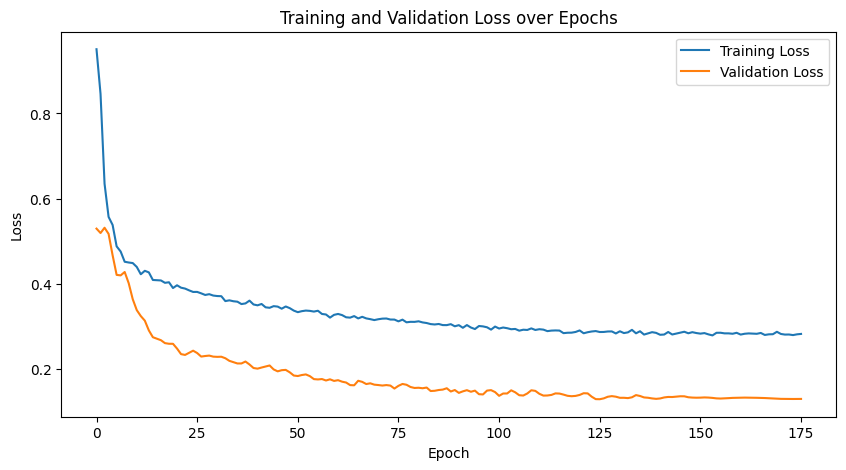

In [68]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

MODEL EVALUTION


Test Data Loss (MAE): 0.1165
Test Physics Loss (MAE): 0.4091
Test Boundary Loss (MAE): 3.4700
Test R² Score: 0.9747


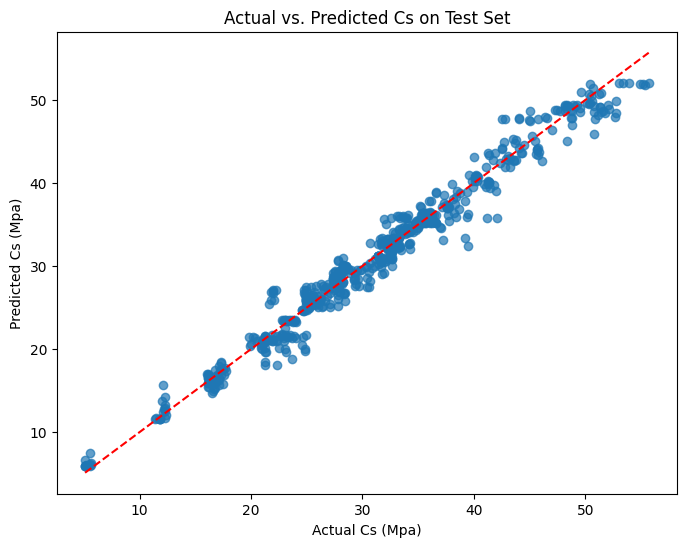

In [75]:
model.eval()
with torch.no_grad():
    test_outputs_scaled = model(X_test_tensor)


    test_outputs = test_outputs_scaled.cpu().numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]
    y_test_original = y_test_tensor.cpu().numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]

    # Convert test_outputs back to torch tensors for loss calculations
    test_outputs_scaled_tensor = torch.tensor(test_outputs_scaled.cpu().numpy(), dtype=torch.float32).to(device)

    # Compute Test Losses
    test_loss_data = criterion_data(test_outputs_scaled_tensor, y_test_tensor)
    test_loss_phy = physics_informed_loss(
        X_test_tensor[:, age_idx].view(-1,1),
        X_test_tensor[:, UPV_idx].view(-1,1),
        X_test_tensor[:, ER_idx].view(-1,1),
        test_outputs_scaled_tensor,
        scaler,
        target_scaler
    )
    test_loss_bnd = boundary_loss(
        test_outputs_scaled_tensor,
        X_test_tensor[:, UPV_idx].view(-1,1),
        X_test_tensor[:, ER_idx].view(-1,1),
        X_test_tensor[:, age_idx].view(-1,1),
        scaler,
        target_scaler
    )

    # Compute R² Score
    r2 = r2_score(y_test_original, test_outputs)

    print(f"\nTest Data Loss (MAE): {test_loss_data.item():.4f}")
    print(f"Test Physics Loss (MAE): {test_loss_phy.item():.4f}")
    print(f"Test Boundary Loss (MAE): {test_loss_bnd.item():.4f}")
    print(f"Test R² Score: {r2:.4f}")

    # Plot Actual vs Predicted
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_original, test_outputs, alpha=0.7)
    plt.plot([y_test_original.min(), y_test_original.max()],
             [y_test_original.min(), y_test_original.max()], 'r--')
    plt.xlabel('Actual Cs (Mpa)')
    plt.ylabel('Predicted Cs (Mpa)')
    plt.title('Actual vs. Predicted Cs on Test Set')
    plt.show()

TESTING MODEL

In [76]:
# Select the first 15 samples from the test set
num_samples = 15
X_test_samples = X_test_tensor[:num_samples]
y_test_samples = y_test_tensor[:num_samples]

# Make predictions
model.eval()
with torch.no_grad():
    predicted_samples_scaled = model(X_test_samples)

    # Inverse transform the predictions to original scale
    predicted_samples = predicted_samples_scaled.cpu().numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]
    y_test_original_samples = y_test_samples.cpu().numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]

# Prepare a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Sample': np.arange(1, num_samples + 1),
    'Actual Cs (Mpa)': y_test_original_samples.flatten(),
    'Predicted Cs (Mpa)': predicted_samples.flatten()
})

print("\nComparison of Actual vs Predicted Cs for 15 Test Samples:")
print(comparison_df)


Comparison of Actual vs Predicted Cs for 15 Test Samples:
    Sample  Actual Cs (Mpa)  Predicted Cs (Mpa)
0        1        21.314301           20.931263
1        2        26.113701           25.689365
2        3        42.915798           42.947414
3        4        41.117500           41.906895
4        5        33.353401           32.385422
5        6        21.822102           26.873512
6        7        27.337900           28.462685
7        8        39.172199           33.418221
8        9        27.071301           25.466934
9       10        52.754303           49.901016
10      11        24.933899           27.486549
11      12        32.527901           31.840765
12      13        36.991299           34.649338
13      14        25.713200           25.556162
14      15        27.821699           26.041069


In [77]:
import random
import numpy as np

# Ensure reproducibility
random.seed(42)

# Number of samples to test
num_samples = 15

# Randomly select 15 unique indices from the test set
selected_indices = random.sample(range(X_test.shape[0]), num_samples)

# Extract the scaled input features for the selected samples
selected_inputs_scaled = X_test.iloc[selected_indices].values  # Shape: (15, 4)

# X_test.columns = ['Type_of_aggregates', 'Curing_age_(days)', 'Er_(ohm-cm)', 'UPV_(m/s)']

# Separate 'Type_of_aggregates' (categorical) and the numerical features
type_of_aggregates = selected_inputs_scaled[:, 0].reshape(-1, 1)  # Shape: (15, 1)

# Extract numerical features in the correct order: ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']
# Assuming X_test.columns are ['Type_of_aggregates', 'Curing_age_(days)', 'Er_(ohm-cm)', 'UPV_(m/s)']
numerical_features_scaled = selected_inputs_scaled[:, [1, 3, 2]]  # ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']

# Inverse scale the numerical features to their original values
inverse_scaled_numerical = scaler.inverse_transform(numerical_features_scaled)  # Shape: (15, 3)

# Current order after inverse_transform: ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']
# Desired order: ['Curing_age_(days)', 'Er_(ohm-cm)', 'UPV_(m/s)']
# Reorder the numerical features
inverse_scaled_numerical_correct_order = inverse_scaled_numerical[:, [0, 2, 1]]  # ['Curing_age_(days)', 'Er_(ohm-cm)', 'UPV_(m/s)']

# Combine 'Type_of_aggregates' with the correctly ordered inverse-scaled numerical features
selected_inputs_original = np.hstack((type_of_aggregates, inverse_scaled_numerical_correct_order))  # Shape: (15, 4)

# Create a DataFrame for inputs with correct column names
inputs_df = pd.DataFrame(selected_inputs_original, columns=X_test.columns)

# Extract the scaled actual Cs values for the selected samples
selected_y_test_scaled = y_test[selected_indices].reshape(-1, 1)  # Shape: (15, 1)

# Inverse scale the actual Cs values to their original scale
selected_y_test = target_scaler.inverse_transform(selected_y_test_scaled).flatten()  # Shape: (15,)

# Convert the selected scaled inputs to PyTorch tensors and move to the appropriate device
selected_inputs_tensor = torch.tensor(selected_inputs_scaled, dtype=torch.float32).to(device)

# Ensure the model is in evaluation mode
model.eval()

with torch.no_grad():
    # Predict the Cs values (scaled) using the model
    selected_y_pred_scaled = model(selected_inputs_tensor).cpu().numpy().flatten()  # Shape: (15,)

# Inverse scale the predicted Cs values to their original scale
selected_y_pred = target_scaler.inverse_transform(selected_y_pred_scaled.reshape(-1, 1)).flatten()  # Shape: (15,)

# Combine inputs, actual Cs, and predicted Cs into a single DataFrame
results_df = inputs_df.copy()
results_df['Actual Cs_(Mpa)'] = selected_y_test
results_df['Predicted Cs_(Mpa)'] = selected_y_pred

# Reorder columns for better readability
results_df = results_df[['Type_of_aggregates', 'Curing_age_(days)', 'Er_(ohm-cm)', 'UPV_(m/s)',
                         'Actual Cs_(Mpa)', 'Predicted Cs_(Mpa)']]

# Display the results
print("\n--- 15 Random Sample Predictions ---\n")
print(results_df.to_string(index=False))


--- 15 Random Sample Predictions ---

 Type_of_aggregates  Curing_age_(days)  Er_(ohm-cm)  UPV_(m/s)  Actual Cs_(Mpa)  Predicted Cs_(Mpa)
                1.0                7.0       5.1051  4326.7813          28.0607           29.558212
                1.0                7.0       4.6279  4341.7631          27.4002           28.396435
                0.0              120.0      16.0962  3530.7411          36.2660           36.142986
                1.0               14.0       4.7520  3651.3488          29.7399           29.465651
                2.0               28.0       5.5346  3248.9439          25.6677           26.887566
                2.0               40.0       4.3802  3491.2494          27.3547           28.634577
                2.0                3.0       3.2691  3306.7258          11.3723           11.589920
                3.0               14.0       3.1620  3287.2198          27.1323           25.081289
                2.0                3.0       3.3528  3106.530

In [72]:
import numpy as np
import torch
import pandas as pd

hard_coded_samples = [
    {'Type_of_aggregates': 0.0, 'Curing_age_(days)': 40, 'Er_(ohm-cm)': 4.4134, 'UPV_(m/s)': 2990.92},
    {'Type_of_aggregates': 1.0, 'Curing_age_(days)': 20, 'Er_(ohm-cm)': 6.0, 'UPV_(m/s)': 3200.0},
    {'Type_of_aggregates': 0.0, 'Curing_age_(days)': 15, 'Er_(ohm-cm)': 5.5, 'UPV_(m/s)': 3100.0},
]

samples_df = pd.DataFrame(hard_coded_samples)

# Get the feature names that the scaler was trained on
original_features = scaler.feature_names_in_

# Ensure the columns in samples_df are in the same order as original_features
samples_df = samples_df[[feature for feature in original_features if feature in samples_df.columns]]

# Now you can safely transform the data
scaled_numerical = scaler.transform(samples_df)

categorical_feature = samples_df[['Type_of_aggregates']].values if 'Type_of_aggregates' in samples_df.columns else np.zeros((samples_df.shape[0], 1))  # Handle case where 'Type_of_aggregates' might be missing
processed_samples = np.hstack((categorical_feature, scaled_numerical))

input_tensor = torch.tensor(processed_samples, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    scaled_predictions = model(input_tensor).cpu().numpy().flatten()

scaled_predictions_reshaped = scaled_predictions.reshape(-1, 1)
actual_predictions = target_scaler.inverse_transform(scaled_predictions_reshaped).flatten()

results = samples_df.copy()
results['Predicted Cs_(Mpa)'] = actual_predictions

print("\Sample Predictions ---\n")
print(results.to_string(index=False))

\Sample Predictions ---

 Curing_age_(days)  UPV_(m/s)  Er_(ohm-cm)  Predicted Cs_(Mpa)
                40    2990.92       4.4134           32.593609
                20    3200.00       6.0000           34.234634
                15    3100.00       5.5000           32.473732


In [73]:
from google.colab import drive
drive.mount('/content/drive')
# Specify a path and filename on your Drive
model_save_path = '/content/drive/MyDrive/testing/concrete_strength_model.pth'

# Save the model's state dictionary (weights and biases)
torch.save(model.state_dict(), model_save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


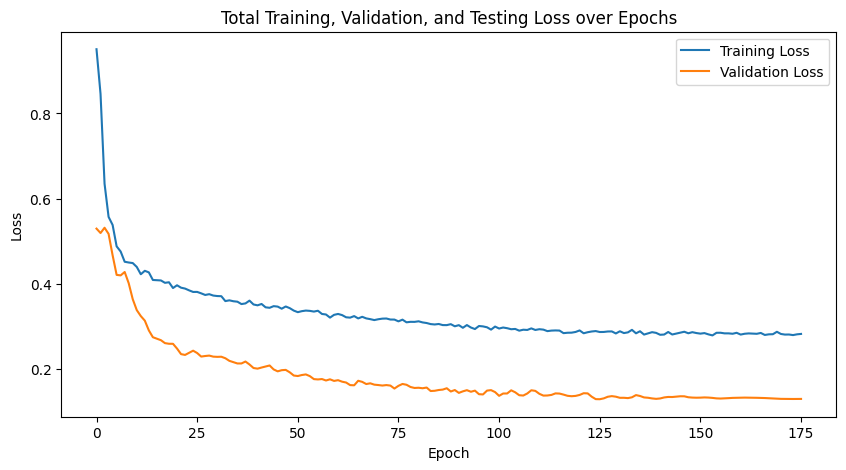

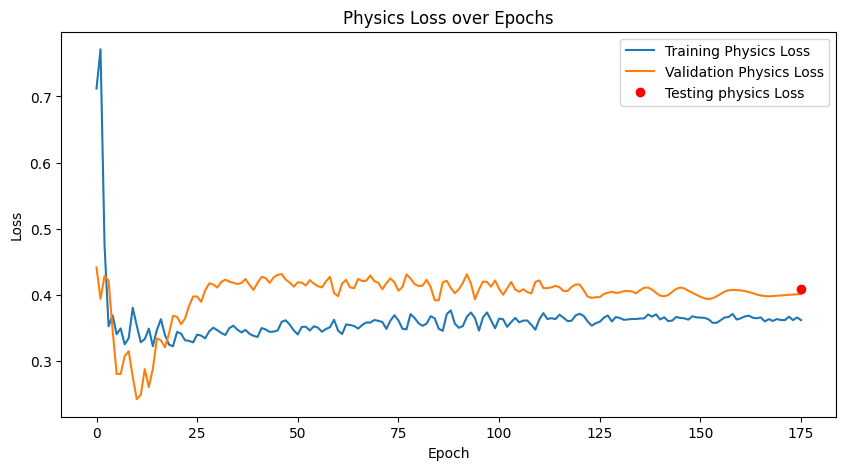

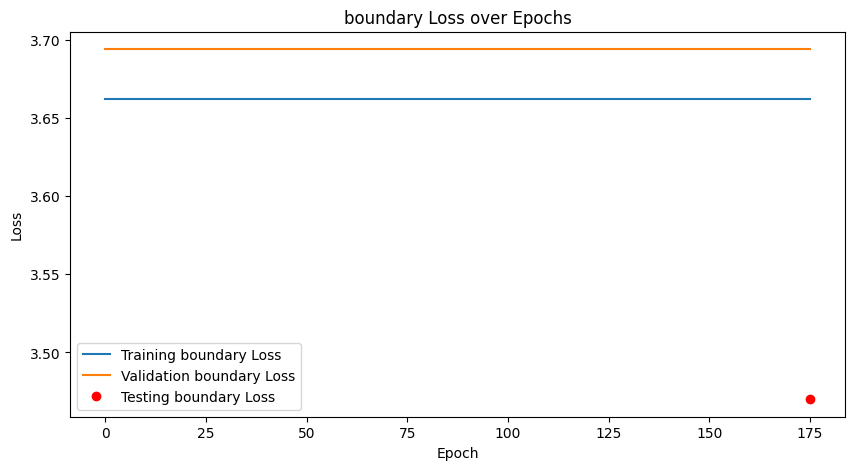

In [74]:
import matplotlib.pyplot as plt

# Plot Total Losses
plt.figure(figsize=(10, 5)) # Fixed: Removed the extra indentation
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Training, Validation, and Testing Loss over Epochs')
plt.legend()
plt.show()

# Plot Physics Losses
plt.figure(figsize=(10, 5)) # Fixed: Removed the extra indentation
plt.plot(train_phy_losses, label='Training Physics Loss')
plt.plot(val_phy_loss_list, label='Validation Physics Loss')
plt.plot([len(train_losses)-1], [test_loss_phy.item()], 'ro', label='Testing physics Loss') # Red dot for testing loss
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Physics Loss over Epochs')
plt.legend()
plt.show()


# Plot boundary Losses
plt.figure(figsize=(10, 5)) # Fixed: Removed the extra indentation
plt.plot(train_bnd_losses, label='Training boundary Loss')
plt.plot(val_bnd_loss_list, label='Validation boundary Loss')
plt.plot([len(train_losses)-1], [test_loss_bnd.item()], 'ro', label='Testing boundary Loss') # Red dot for testing loss
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('boundary Loss over Epochs')
plt.legend()
plt.show()

'y_test_original' and 'test_outputs' which store the real and predicted

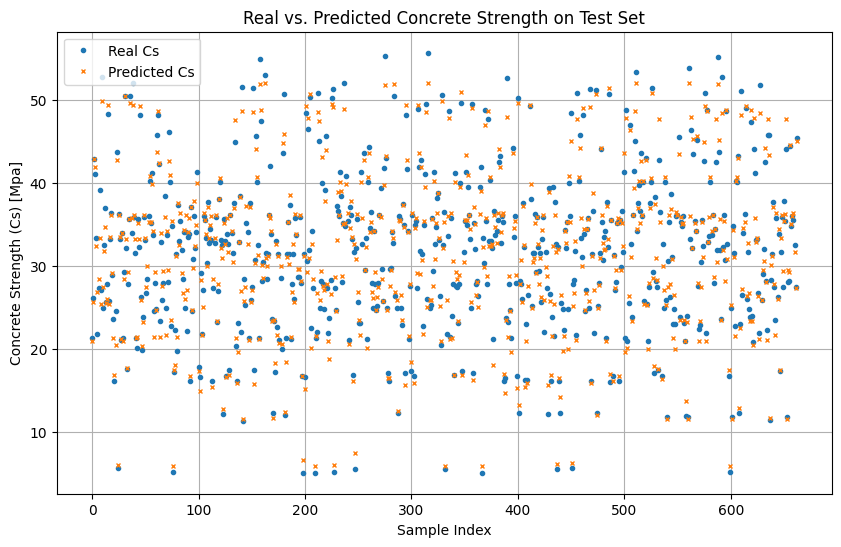

In [80]:
import matplotlib.pyplot as plt
import numpy as np


y_test_np = y_test_original
test_pred_np = test_outputs

# Additional Visualization: Real vs Predicted Cs on Test Set
plt.figure(figsize=(10, 6))
plt.plot(y_test_np, label='Real Cs', marker='o', linestyle='None', markersize=3)
plt.plot(test_pred_np, label='Predicted Cs', marker='x', linestyle='None', markersize=3)
plt.xlabel('Sample Index')
plt.ylabel('Concrete Strength (Cs) [Mpa]')
plt.title('Real vs. Predicted Concrete Strength on Test Set')
plt.legend()
plt.grid(True)
plt.show()